In [4]:
import pandas as pd
import xgboost as xgb
import json, os, glob, kagglehub
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Downloads e Caminhos
path_sb = kagglehub.dataset_download("saurabhshahane/statsbomb-football-data")

def carregar_temporada(comp_id, season_id):
    path_matches = os.path.join(path_sb, "data", "matches", str(comp_id), f"{season_id}.json")
    with open(path_matches, "r", encoding="utf-8") as f:
        matches = json.load(f)
    ids = [m['match_id'] for m in matches]
    
    records = []
    for mid in ids[:100]: # Limitando para 100 jogos para manter a performance
        f_path = os.path.join(path_sb, "data", "events", f"{mid}.json")
        if os.path.exists(f_path):
            with open(f_path, "r", encoding="utf-8") as f:
                events = json.load(f)
                for e in events: e['match_id'] = mid
                records.extend(events)
    return pd.json_normalize(records)

print("⏳ Carregando bases históricas...")
df_1516 = carregar_temporada(11, 27) # La Liga 15/16
df_1718 = carregar_temporada(11, 1)  # La Liga 17/18

⏳ Carregando bases históricas...


In [5]:
import numpy as np

def processar_stats_taticas(df):
    # 1. Criando métricas base (Booleanas)
    df['is_goal'] = (df['shot.outcome.name'] == 'Goal').astype(int)
    df['is_pass'] = (df['type.name'] == 'Pass').astype(int)
    df['is_defensive'] = df['type.name'].isin(['Duel', 'Interception']).astype(int)
    
    # Coordenada X (Zona de Calor: 0 a 120)
    df['pos_x'] = df['location'].apply(lambda loc: loc[0] if isinstance(loc, list) else None)

    # 2. Agregação por Jogador
    stats = df.groupby(['player.name', 'team.name']).agg({
        'is_goal': 'sum',
        'is_pass': 'sum',
        'is_defensive': 'sum',
        'pos_x': 'mean',
        'shot.statsbomb_xg': 'sum',
        'pass.goal_assist': 'sum', # Adicionado para medir criação real
        'type.name': 'count'
    }).rename(columns={
        'is_goal': 'Gls_Total',
        'is_pass': 'Passes_Total',
        'is_defensive': 'Acoes_Defensivas',
        'pos_x': 'Zona_Media_X',
        'pass.goal_assist': 'Assists',
        'type.name': 'Event_Volume',
        'shot.statsbomb_xg': 'xG_Total'
    }).reset_index()

    # 3. --- MÉTRICAS DE EFICIÊNCIA (O "DNA" do Jogador) ---
    
    # Eficiência de Finalização: Ele faz mais gols do que o esperado pela física (xG)?
    # Usamos .replace(0, np.nan) para evitar divisão por zero, depois fillna(0)
    stats['Eficiencia_Chute'] = stats['Gls_Total'] / stats['xG_Total'].replace(0, np.nan)
    
    # Periculosidade por Passe: Quantas assistências ele gera por passe tentado?
    stats['Periculosidade_Passe'] = stats['Assists'] / stats['Passes_Total'].replace(0, np.nan)
    
    # Densidade de Perigo: Quanto xG ele gera a cada 100 ações?
    stats['Expectativa_por_Acao'] = (stats['xG_Total'] / stats['Event_Volume'].replace(0, np.nan)) * 100

    return stats.fillna(0)

# Processando as duas temporadas com a nova lógica
player_stats_2015 = processar_stats_taticas(df_1516)
player_stats_2017 = processar_stats_taticas(df_1718)

print("✅ Métricas de eficiência calculadas para 2015 e 2017.")

✅ Métricas de eficiência calculadas para 2015 e 2017.


✅ XGBoost treinado com sucesso.
✅ RandomForest treinado com sucesso.
✅ Logit treinado com sucesso.


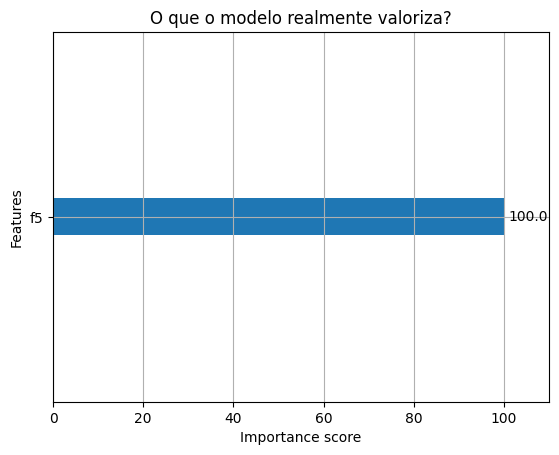

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

# 1. Lista de Features Alinhada com a Função de Eficiência
# Removemos os nomes genéricos e focamos na "Métrica por Jogador"
features = [
    'Passes_Total', 
    'Acoes_Defensivas', 
    'Zona_Media_X', 
    'xG_Total', 
    'Event_Volume',
    'Eficiencia_Chute',      # Gols por xG (Métrica de Elite)
    'Periculosidade_Passe',  # Assistências por Passe
    'Expectativa_por_Acao'   # xG gerado a cada 100 toques
]

# 2. Preparar os dados (Treino 2015/2016)
X_train = player_stats_2015[features].fillna(0)
y_train = (player_stats_2015['Gls_Total'] > 0.5).astype(int) # Alvo: Marcar ao menos 1 gol

# 3. Escalonamento (Obrigatório para Logit e PCA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 4. Inicializar o "Zoológico"
models = {
    "XGBoost": xgb.XGBClassifier(eval_metric='logloss', learning_rate=0.05, max_depth=4),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logit": LogisticRegression()
}

# 5. Treinar e Validar
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"✅ {name} treinado com sucesso.")

# Verificar Importância das Features no XGBoost
xgb.plot_importance(models["XGBoost"])
plt.title("O que o modelo realmente valoriza?")
plt.show()

In [7]:
# 1. Alinhamento de Features (Obrigatório ser IGUAL ao treino)
features = [
    'Passes_Total', 
    'Acoes_Defensivas', 
    'Zona_Media_X', 
    'xG_Total', 
    'Event_Volume',
    'Eficiencia_Chute', 
    'Periculosidade_Passe', 
    'Expectativa_por_Acao'
]

# 2. Localizar o Messi na base de 2017/2018
messi_17 = player_stats_2017[player_stats_2017['player.name'].str.contains('Messi')]

if not messi_17.empty:
    # Isolar as colunas de teste
    X_test_messi = messi_17[features].fillna(0)
    
    # Aplicar o MESMO scaler que treinou os dados de 2015
    X_test_scaled = scaler.transform(X_test_messi)

    print(f"📈 MÉTRICAS DE EFICIÊNCIA - MESSI (Temporada 17/18):")
    print(f"🔹 Volume de Eventos: {messi_17['Event_Volume'].values[0]}")
    print(f"🔹 Posição Média (Ataque): {messi_17['Zona_Media_X'].values[0]:.2f} metros")
    print(f"🔹 Eficiência de Chute (Gols/xG): {messi_17['Eficiencia_Chute'].values[0]:.2f}")
    
    print("\n🔮 PROBABILIDADE DE SUCESSO (PREDIÇÃO):")
    print("-" * 40)
    for name, model in models.items():
        # [0][1] extrai a probabilidade da classe 1 (Artilheiro)
        prob = model.predict_proba(X_test_scaled)[0][1]
        
        # Estilizando a saída para facilitar a leitura
        status = "🔥 ELITE" if prob > 0.8 else "✅ ALTA" if prob > 0.5 else "⚠️ MÉDIA/BAIXA"
        print(f"{name:12} 🤖 {prob:6.2%} | Status: {status}")
    print("-" * 40)
else:
    print("❌ Messi não encontrado na amostra 17/18. Verifique o carregamento dos JSONs.")

📈 MÉTRICAS DE EFICIÊNCIA - MESSI (Temporada 17/18):
🔹 Volume de Eventos: 7832
🔹 Posição Média (Ataque): 79.51 metros
🔹 Eficiência de Chute (Gols/xG): 1.43

🔮 PROBABILIDADE DE SUCESSO (PREDIÇÃO):
----------------------------------------
XGBoost      🤖 98.99% | Status: 🔥 ELITE
RandomForest 🤖 99.00% | Status: 🔥 ELITE
Logit        🤖 100.00% | Status: 🔥 ELITE
----------------------------------------


In [8]:
# 1. Localizar o Suárez na base de 2017/2018
suarez_17 = player_stats_2017[player_stats_2017['player.name'].str.contains('Suárez')]

if not suarez_17.empty:
    # Isolar as colunas de teste (as mesmas 8 que usamos no treino)
    X_test_suarez = suarez_17[features].fillna(0)
    
    # Aplicar o MESMO scaler do treino de 2015
    X_test_scaled_suarez = scaler.transform(X_test_suarez)

    print(f"🔫 MÉTRICAS DE PERFORMANCE - LUIS SUÁREZ (17/18):")
    print(f"🔹 Gols na Amostra: {suarez_17['Gls_Total'].values[0]}")
    print(f"🔹 Eficiência de Chute (Gols/xG): {suarez_17['Eficiencia_Chute'].values[0]:.2f}")
    print(f"🔹 Posição Média (X): {suarez_17['Zona_Media_X'].values[0]:.2f} metros")
    
    print("\n🔮 PROBABILIDADE DE SUCESSO (SUÁREZ):")
    print("-" * 40)
    for name, model in models.items():
        prob = model.predict_proba(X_test_scaled_suarez)[0][1]
        status = "🔥 ELITE" if prob > 0.8 else "✅ ALTA" if prob > 0.5 else "⚠️ MÉDIA"
        print(f"{name:12} 🤖 {prob:6.2%} | Status: {status}")
    print("-" * 40)
else:
    print("❌ Luis Suárez não encontrado na amostra 17/18.")

🔫 MÉTRICAS DE PERFORMANCE - LUIS SUÁREZ (17/18):
🔹 Gols na Amostra: 0
🔹 Eficiência de Chute (Gols/xG): 0.00
🔹 Posição Média (X): 51.45 metros

🔮 PROBABILIDADE DE SUCESSO (SUÁREZ):
----------------------------------------
XGBoost      🤖  0.42% | Status: ⚠️ MÉDIA
RandomForest 🤖  0.00% | Status: ⚠️ MÉDIA
Logit        🤖  0.56% | Status: ⚠️ MÉDIA
----------------------------------------


In [ ]:
from huggingface_hub import InferenceClient

import os
from dotenv import load_dotenv
from huggingface_hub import InferenceClient

load_dotenv()

token = os.getenv("HF_TOKEN")

if not token:
    raise ValueError("❌ Erro: HF_TOKEN não encontrado no arquivo .env")



client = InferenceClient(model="Qwen/Qwen2.5-7B-Instruct", token=token)

def analisar_performance_messi_hf(stats, prob_modelo):
    dados_reais = {
        "Gols": stats['Gls_Total'].values[0],
        "xG": stats['xG_Total'].values[0],
        "Eficiência": stats['Eficiencia_Chute'].values[0],
        "Probabilidade_XGBoost": f"{prob_modelo:.2%}"
    }
    
    # Prompt estruturado para um analista tático
    prompt = f"""
    Aja como um analista de futebol profissional.
    Analise estes dados do Messi (17/18): {dados_reais}.
    O modelo XGBoost deu uma probabilidade de {prob_modelo:.2%} para ele ser elite.
    Dê um veredito de no máximo 3 frases sobre a eficiência dele.
    """
    
    try:
        # Usando a estrutura de mensagens que o Qwen entende bem
        response = client.chat_completion(
            messages=[{"role": "user", "content": prompt}],
            max_tokens=250,
            temperature=0.7
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"Erro na Hugging Face (Qwen): {e}"

if not messi_17.empty:
    prob_messi = models["XGBoost"].predict_proba(X_test_scaled)[0][1]
    resultado = analisar_performance_messi_hf(messi_17, prob_messi)
    print(f"🎙️ ANALISTA (Qwen 2.5 via HF):\n{resultado}")

🎙️ ANALISTA (Qwen 2.5 via HF):
Com base nos dados fornecidos, podemos concluir que Lionel Messi teve uma eficiência excepcional na temporada 17/18, com 1,43 gols por cada xG (ou esperança de gols), indicando que ele tendeu a marcar mais gols do que o esperado. A alta probabilidade de 98,99% de ser classificado como elite pelo modelo XGBoost também reforça sua performance extraordinária naquela temporada.
